<a href="https://colab.research.google.com/github/ArseniyFaryna/Intelligent_analisis_labs/blob/main/%D0%9B%D0%A02_%D0%B7%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_%D1%81%D1%82%D1%83%D0%B4%D0%B5%D0%BD%D1%82%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [1]:
ПІБ = 'Фарина Арсеній'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-31'      # напр. 'КН-31'
ВАРІАНТ = 18    # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [2]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 18 · Фарина Арсеній, ШІ-31, «Longer Boats»
Підприємство «Longer Boats» виготовляє яхти. Одиниця виміру плану: шт./місяць.

                       Sting  Ray  Breaker  Marlin  ЗАПАС
Склопластик, м²            2    3        0       1   1217
Столярний цех, год         0    6        1       6    668
Фарбувальний цех, год      1    0        4       1    923
Такелаж, компл.            2    6        3       4   1040
Ділянка добудови, год      3    1        6       5    619

                    Sting  Ray  Breaker  Marlin
Прибуток з одиниці     66   54       18      66

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Ділянка добудови, год
  ціна:   34.9 за одиницю
  обсяг:  до 100 одиниць


In [3]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення: x1 - кількість яхт Sting (шт./місяць), x2 - кількість яхт Ray (шт./місяць), x3 - кількість яхт Breaker (шт./місяць), x4 - кількість яхт Marlin (шт./місяць)

Цільова функція: 66*x1 + 54*x2 + 18*x3 + 66*x4 --> max

Обмеження:
Склопластик, м²:            2*x1 + 3*x2 + 0*x3 + 1*x4 <= 1217

Столярний цех, год:         0*x1 + 6*x2 + 1*x3 + 6*x4 <= 668

Фарбувальний цех, год:      1*x1 + 0*x2 + 4*x3 + 1*x4 <= 923

Такелаж, компл.:            2*x1 + 6*x2 + 3*x3 + 4*x4 <= 1040

Ділянка добудови, год:      3*x1 + 1*x2 + 6*x3 + 5*x4 <= 619

Невід'ємність: x1, x2, x3, x4 >= 0


### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:** Параметр - це вхідні дані, які є незмінними, а змінна рішення вона змінюється й ми повинні знайти її. Якщо запас ресурсу не буде параметром, а - змінною рішення, то тоді задача стає необмеженою, ми зможемо нескінченно збільшувати параметр, і разом з тим цільова функція буде необмежено зростати, ми не знайдемо оптимальний розв'язок. По суті не існує оптимуму без належного обмеження.

---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [4]:
# впишіть числа, які дав Excel
EXCEL_ПЛАН    = [169.2222222, 111.3333333, 0, 0]     # оптимальний випуск кожного виробу
EXCEL_ПРИБУТОК = 17180.6667            # значення цільової функції

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [169.2222222, 111.3333333, 0, 0] | прибуток 17180.6667


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [5]:
# ВАШ КОД
from scipy.optimize import linprog

coefficients = [-66, -54, -18, -66]
A_ub = [
    [2,3,0,1],
    [0,6,1,6],
    [1,0,4,1],
    [2,6,3,4],
    [3,1,6,5]
]
b_ub = [1217, 668, 923, 1040, 619]
bounds = [(0, None)] * 4

result = linprog(c=coefficients, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

план = result.x
прибуток = -result.fun

**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [6]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
|Склопластик, м² |  672.4444444|0  |1217  |1E+30  |544.556
|Столярний цех, год  |668  |5.3333333  |668  |37.75  |668  |
|Фарбувальний цех, год  |169.2222222  |0  |923  |1E+30  |753.778 |
|Такелаж, компл.  |1006.4444444  |0  |1040  |1E+30  |33.556  |
|Ділянка добудови, год  |619  |22  |619  |50.3333333  |507.667  |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?**
Для цього порівнюємо дві колонки кінцеве значення (скільки реально витрачено) із колонкою права частина (скільки було в запасі). Якщо кінцеве значення дорівнює правій частин, то ресурс витратили повністю і він у дефіциті, якщо кінцеве значення менше за праву частину, то ресурс у надлишку, він необмежує виробництво. У моєму випадку у дефіциті столярний цех і ділянка добудови, а в надлишку такі ресурси склопластик, фарбувальний цех, такелаж. Також можна сказати за тіньовою ціною, якщо дорівнює 0 то дефіцит, а якщо не дорівнює то надлишок.

### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
|Sting  |169.2222222  |0  |66  |96  |57  |
|Ray  |111.3333333  |0  |54  |1E+30  |32  |
|Breaker  |0  |-119.3333333  |18  |119.3333333  |1E+30  |
|Marlin  |0  |-76  |66  |76  |1E+30  |

**У вашому варіанті принаймні один виріб не виробляється зовсім.**
Який саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план?
Звідки ви взяли це число?

Не виробляється Marlin і Breaker також, з ще більшим розривом. Прибуток з одиниці Marlin має зрости на 76 грн, а з Breaker на 142 грн відповідно, щоб він увійшов у план. Це число — колонка Reduced Cost зі звіту про стійкість, і воно обчислюється як різниця між прибутком виробу і вартістю ресурсів, які пішли б на нього, оціненою за тіньовими цінами дефіцитних ресурсів у нашому випадку - столярний цех і ділянка побудови.

---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [7]:
# ВАШ КОД
coefficients = [-66, -54, -18, -66]
A_ub = [
    [2,3,0,1],
    [0,6,1,6],
    [1,0,4,1],
    [2,6,3,4],
    [3,1,6,5]
]
b_old = [1217, 668, 923, 1040, 619]
b_new = [1217, 668, 923, 1040, 620]
bounds = [(0, None)] * 4

result_new = linprog(c=coefficients, A_ub=A_ub, b_ub=b_new, bounds=bounds, method='highs')
result_old = linprog(c=coefficients, A_ub=A_ub, b_ub=b_old, bounds=bounds, method='highs')

print(f" Прибуток до зміни: {-result_old.fun}")
print(f" Прибуток після зміни: {-result_new.fun}")
print(f" Приріст прибутку: {-result_new.fun - (-result_old.fun)}")

 Прибуток до зміни: 17180.666666666668
 Прибуток після зміни: 17202.666666666668
 Приріст прибутку: 22.0


**Відповідь 5.1:** *(приріст прибутку = 22.0, тіньова ціна зі звіту = 22.0, збігаються?)* Так збігаються

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

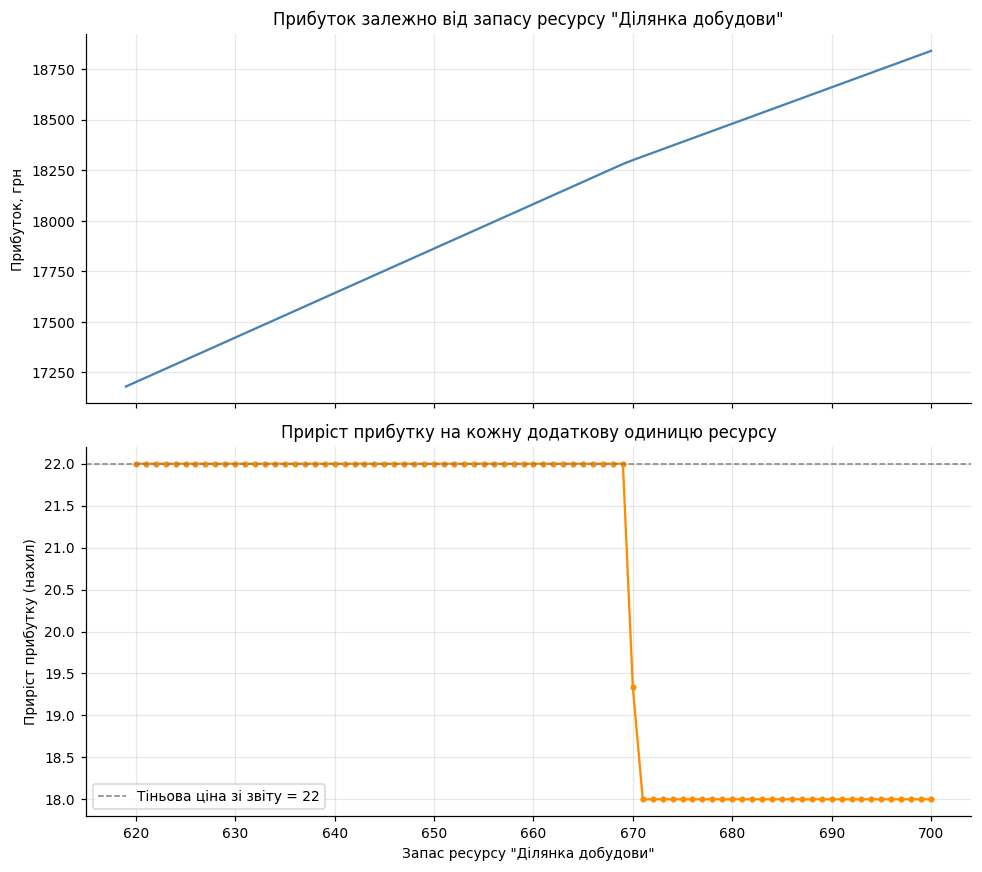

In [8]:
# ВАШ КОД
from scipy.optimize import linprog

coefficients = [-66, -54, -18, -66]
A_ub = [
    [2,3,0,1],
    [0,6,1,6],
    [1,0,4,1],
    [2,6,3,4],
    [3,1,6,5]
]
b_ub = [1217, 668, 923, 1040]

bounds = [(0, None)] * 4

start = 619
end = 700
values = list(range(start, end + 1))
profits = []

for v in values:
    b_ub.append(v)
    result = linprog(c=coefficients, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
    profits.append(-result.fun)
    b_ub.pop()

increments = [profits[i] - profits[i-1] for i in range(1, len(profits))]
increment_x = values[1:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

ax1.plot(values, profits, color='steelblue')
ax1.set_ylabel('Прибуток, грн')
ax1.set_title('Прибуток залежно від запасу ресурсу "Ділянка добудови"')
ax1.grid(True, alpha=0.3)

ax2.plot(increment_x, increments, color='darkorange', marker='o', markersize=3)
ax2.axhline(22, color='gray', linestyle='--', linewidth=1, label='Тіньова ціна зі звіту = 22')
ax2.set_xlabel('Запас ресурсу "Ділянка добудови"')
ax2.set_ylabel('Приріст прибутку (нахил)')
ax2.set_title('Приріст прибутку на кожну додаткову одиницю ресурсу')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Відповідь 5.2:** *(на скільки одиниць можна збільшити запас, доки тіньова ціна не зміниться;
чи збігається знайдена межа з «допустимим збільшенням» зі звіту Excel)*

Запас ділянки добудови можна збільшувати до 669, оскільки потім тіньова ціна починає падати. Так допустиме збільшення зі звіту Excel цілком збігається із знайденою межею - 50

---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [9]:
# ВАШ КОД
from scipy.optimize import linprog

coefficients = [-66, -54, -18, -66]
A_ub = [
    [2,3,0,1],
    [0,6,1,6],
    [1,0,4,1],
    [2,6,3,4],
    [3,1,6,5]
]
b_base = [1217, 668, 923, 1040, 619]
bounds = [(0, None)] * 4

result = linprog(coefficients, A_ub=A_ub, b_ub=b_base, bounds=bounds, method='highs')
profit_base = -result.fun

shadow_price = 22.0
supplier_price = 34.9
allowable_increase = 50.33
max_offer = 100

print("Питання 1")
if supplier_price > shadow_price:
  print(f"Купувати не вигідно")
elif supplier_price < shadow_price:
  print("Купувати вигідно")

print("\nПитання 2")
if shadow_price <= supplier_price:
  quantity_to_buy = 0
else:
  quantity_to_buy = min(allowable_increase, max_offer)
print("Оптимальна кількість для купівлі:", quantity_to_buy)

print("\nФормула через тіньову ціну (аналітична перевірка)")
gain_per_unit = shadow_price - supplier_price
print("Виграш на одну одиницю ресурсу:", gain_per_unit)

print("\nПитання 3")
quantities = list(range(0, max_offer + 1))
gains = []

for qty in quantities:
    b_new = b_base[:4] + [b_base[4] + qty]
    res = linprog(coefficients, A_ub=A_ub, b_ub=b_new, bounds=bounds, method='highs')
    gross_profit = -res.fun
    cost = qty * supplier_price
    net_profit = gross_profit - cost
    gain = net_profit - profit_base
    gains.append(gain)

best_gain = max(gains)
best_qty = quantities[gains.index(best_gain)]
print("Найкращий варіант: quantities =", best_qty, " виграш =", round(best_gain, 2))
print("Формула дає для quantities = 100", gain_per_unit * 100, " | цикл дає:", round(gains[100], 2))

Питання 1
Купувати не вигідно

Питання 2
Оптимальна кількість для купівлі: 0

Формула через тіньову ціну (аналітична перевірка)
Виграш на одну одиницю ресурсу: -12.899999999999999

Питання 3
Найкращий варіант: quantities = 0  виграш = 0.0
Формула дає для quantities = 100 -1289.9999999999998  | цикл дає: -1488.67


**Відповідь 6.1:**

* Брати чи ні і чому: Ні, не брати. Оскільки тіньова ціна ресурсу менша за ціну постачальника, то кожна одиниця коштує більше, ніж приносить прибутку

* Скільки одиниць має сенс купити і чому не більше: Немає сенсу купувати, оскільки тіньова ціна нижча за ціну вже на першій одиниці й лишається такою на всьому діапазоні дії (до 50.33 од. за звітом про стійкість), жодна кількість не вигідна.

* Очікуваний виграш: Відʼємний. За формулою (22 − 34.9) * quantities = −12.9 грн на кожну куплену одиницю — тобто чистий збиток, що зростає пропорційно обсягу закупівлі.

* Перевірка прямим розв'язанням дала: Для максмимальної пропозиції, купити 100 - валовий прибуток зростає до 19182.0 грн, але після відрахування витрат за перевезення 100*34.9=3490 грн чистий прибуток рівний 15692.0 грн — на 1488.67 грн менше за базовий 17180.67 грн. Перебір усіх варіантів qty від 0 до 100 показав, що найкращий варіант — це не купувати


---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [10]:
# ВАШ КОД
from scipy.optimize import linprog

coefficients = [-66, -54, -18, -66]
A_ub = [
    [2,3,0,1],
    [0,6,1,6],
    [1,0,4,1],
    [2,6,3,4],
    [3,1,6,5]
]
b_base = [1217, 668, 923, 1040, 619]
bounds = [(0, None)] * 4

result = linprog(coefficients, A_ub=A_ub, b_ub=b_base, bounds=bounds, method='highs')

ненульових = sum(1 for x in result.x if x > 1e-6)
звязних = sum(1 for s in result.slack if s < 1e-6)

In [11]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 2 | зв’язних обмежень: 2
Етап 7 пройдено


**Відповідь 7.1:** *(чи збіглися числа; що означала б розбіжність на практиці)*

Так, числа збіглися (2 ненульових виробів = 2 зв'язних обмеження).

Розбіжність на практиці означала б, що оптимальна вершина вироджена
— тобто якась базисна змінна випадково дорівнює нулю, або кількість активних
обмежень не відповідає кількості вимірів задачі. Це сигнал перевірити розв'язок
ще раз, можливо, є кілька рівноцінних оптимальних планів, або похибка округлення
завадила правильно визначити, які обмеження справді активні.

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [12]:
# ВАШ КОД
from scipy.optimize import linprog
import numpy as np

coefficients = [-66, -54, -18, -66]
A_ub = [
    [2,3,0,1],
    [0,6,1,6],
    [1,0,4,1],
    [2,6,3,4],
    [3,1,6,5]
]
b_base = [1217, 668, 923, 1040, 619]
bounds = [(0, None)] * 4

result1 = linprog(coefficients, A_ub=A_ub, b_ub=b_base, bounds=bounds, method='highs')
profit1 = -result.fun


print("Розв'язок без умови цілочисельності:")
print("x =", result1.x)
print("Прибуток =", profit1)

x_rounded = np.round(result1.x)
profit_rounded = sum(coefficients[j] * x_rounded[j] for j in range(4)) * -1
print("\nОкруглений план")
print("x округлені =", x_rounded)

usage = [sum(A_ub[i][j] * x_rounded[j] for j in range(4)) for i in range(5)]
feasible = all(usage[i] <= b_base[i] + 1e-6 for i in range(5))

print("\nВитрачено ресурсів:", usage)
print("Запаси:", b_base)
if feasible:
  print("План допустимий")
  print("Прибуток округлений = ", profit_rounded)
else:
  print("План не допустимий і прибуток теж")

print("\nЦілочисельний оптимум задопомогою linprog")
result2 = linprog(coefficients, A_ub=A_ub, b_ub=b_base, bounds=bounds, method='highs', integrality=1)
profit2 = -result2.fun
print("x =", result2.x)
print("Прибуток =", profit2)

Розв'язок без умови цілочисельності:
x = [169.22222222 111.33333333   0.           0.        ]
Прибуток = 17180.666666666668

Округлений план
x округлені = [169. 111.   0.   0.]

Витрачено ресурсів: [np.float64(671.0), np.float64(666.0), np.float64(169.0), np.float64(1004.0), np.float64(618.0)]
Запаси: [1217, 668, 923, 1040, 619]
План допустимий
Прибуток округлений =  17148.0

Цілочисельний оптимум задопомогою linprog
x = [169. 111.   0.   0.]
Прибуток = 17148.0


**Відповідь 8.1:**

| Варіант | План | Прибуток | Допустимий? |
|---|---|---|---|
| без умови цілочисельності |169.22222222, 111.33333333, 0, 0  |17180.66666668  |Так  |
| округлений |169, 111, 0, 0  |17148  |Так  |
| цілочисельний оптимум |169, 111, 0, 0  |17148  |Так  |

**Висновок:** *(чи можна округлювати і чому)*
У даному випадку округлювати можна, оскільки округлений план виявився допустимим і прибуток точно збігається зі справжнім цілочисельним оптимумом, який дав linprog. Округлювати добре не завжди, воно не гарантує ані допустимості (могло би перевищити запас ресурсу при округленні
вгору), ані оптимальності серед цілих чисел (могло б дати гірший прибуток,
ніж справжній цілочисельний оптимум). Краще використовувати вбудовану бібліотеку з integrality=1.


---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [13]:
# ВАШ КОД — впишіть свої дані
постачальники = ['Фастів', 'Апостолове', 'Рівне']            # напр. ['Шостка', 'Енергодар', 'Вінниця']
споживачі     = ['Афанасіївка', 'Ромни', 'Стрий', 'Енергодар']            # напр. ['Тернопіль', 'Афанасіївка', 'Рівне', 'Апостолове']
D = np.array([
    [562, 307, 605, 733],
    [132, 537, 888, 304],
    [824, 558, 282, 1047]
])              # матриця відстаней 3 x 4, км
запас = [10, 15, 15]                    # 3 числа
попит = [20, 10, 5, 5]                    # 4 числа

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Афанасіївка,Ромни,Стрий,Енергодар
Фастів,562,307,605,733
Апостолове,132,537,888,304
Рівне,824,558,282,1047


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [14]:
# ВАШ КОД — розв'язок 1
from scipy.optimize import linprog

A_eq = np.array([
    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1],

    [1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1]
])

b_eq = np.concatenate([запас, попит])
bounds = [(0, None)] * 12

result = linprog(c=D.flatten(), A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

print("Оптимальний план перевезень за допомого linprog:")
print(result.x.reshape(3, 4))
print("Сумарна вартість:", result.fun)
print("Тіньові ціни :", result.eqlin.marginals)

Оптимальний план перевезень за допомого linprog:
[[ 5. -0.  0.  5.]
 [15.  0.  0.  0.]
 [ 0. 10.  5.  0.]]
Сумарна вартість: 15445.0
Тіньові ціни : [ 430.   -0.  681.  132. -123. -399.  303.]


In [15]:
# ВАШ КОД — розв'язок 2

from pulp import LpProblem, LpVariable, LpMinimize, lpSum, LpStatus, value

n_supply = len(запас)
n_demand = len(попит)

prob = LpProblem("Transport", LpMinimize)

x = [[LpVariable(f"x_{i}_{j}", lowBound=0) for j in range(n_demand)] for i in range(n_supply)]

prob += lpSum(D[i][j] * x[i][j] for i in range(n_supply) for j in range(n_demand))

supply_constraints = []
for i in range(n_supply):
    c = lpSum(x[i][j] for j in range(n_demand)) == запас[i]
    prob += c
    supply_constraints.append(c)

demand_constraints = []
for j in range(n_demand):
    c = lpSum(x[i][j] for i in range(n_supply)) == попит[j]
    prob += c
    demand_constraints.append(c)

prob.solve()

print("Розв'язок за допомогою PuLP")
print("Статус:", LpStatus[prob.status])
print("Оптимальний план перевезень:")
for i in range(n_supply):
    print([value(x[i][j]) for j in range(n_demand)])

print("Сумарна вартість:", value(prob.objective))

print("\nТіньові ціни (постачання):")
for i, c in enumerate(supply_constraints):
    print(f"  Постачальник {i}: {c.pi}")

print("Тіньові ціни (попит):")
for j, c in enumerate(demand_constraints):
    print(f"  Споживач {j}: {c.pi}")

Розв'язок за допомогою PuLP
Статус: Optimal
Оптимальний план перевезень:
[5.0, 0.0, 0.0, 5.0]
[15.0, 0.0, 0.0, 0.0]
[0.0, 10.0, 5.0, 0.0]
Сумарна вартість: 15445.0

Тіньові ціни (постачання):
  Постачальник 0: 430.0
  Постачальник 1: 0.0
  Постачальник 2: 681.0
Тіньові ціни (попит):
  Споживач 0: 132.0
  Споживач 1: -123.0
  Споживач 2: -399.0
  Споживач 3: 303.0


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [16]:
# ВАШ КОД — порівняння
import numpy as np

shadow_scipy = np.array([430, -0, 681, 132, -123, -399, 303])
scipy_supply = shadow_scipy[:3]
scipy_demand = shadow_scipy[3:]

shadow_pulp = np.array([430, 0, 681, 132, -123, -399, 303])
pulp_supply = shadow_pulp[:3]
pulp_demand = shadow_pulp[3:]

diff_supply = scipy_supply - pulp_supply
diff_demand = scipy_demand - pulp_demand

print("Різниця між постачальниками:", diff_supply)
print("Різниця між споживачами:", diff_demand)

Різниця між постачальниками: [0 0 0]
Різниця між споживачами: [0 0 0 0]


**Відповідь 10.2:**

* Вартість у двох розв'язувачів:

  Одинакова у двох методах.
* Тіньові ціни збіглися чи ні:

  Так, тіньові ціні збіглися точно, різниця між ними рівна 0.
* Яку закономірність ви побачили в різниці:

  Різниця між scipy і PuLP дорівнює
  нулю окремо для кожного постачальника і окремо для кожного споживача.
  Це є частковим випадком загальної закономірності транспортної задачі,
  оскільки одне з 7 рівнянь лінійно залежне від інших (сумарний запас =
  сумарному попиту), тіньові ціни визначені лише з точністю до довільної константи C — тобто scipy_supply = pulp_supply + C
  і scipy_demand = pulp_demand − C для якогось C. У нашому випадку обидва
  розв'язувачі випадково обрали однакову точку відліку, тому C = 0,
  і числа збіглися буквально.
* Що це означає для того, хто збирається ухвалювати рішення за цим звітом:
  
  Абсолютні значення тіньових
  цін самі по собі можуть залежати від того, який розв'язувач і яку базову
  точку він обрав — тому не варто інтерпретувати одне окреме число як
  "істина". Натомість різниці між тіньовими цінами різних
  постачальників/споживачів (наприклад, "постачальник 2 цінніший за
  постачальника 0 на 251") — це стабільна, відтворювана величина, яка
  не залежить від вибору розв'язувача, і саме на неї варто спиратись
  при ухваленні рішень (наприклад, куди вигідніше розширювати постачання).

---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [17]:
# ВАШ КОД
nonzero_routes = sum(1 for x in result.x if x > 1e-6)
print("Ненульових перевезень:", nonzero_routes)
print("Порівняння з кількістю ненульвих перевезень =", 3+4)
print("Порівняння з кількістю зв'язних перевезень =", 3+4-1)

Ненульових перевезень: 5
Порівняння з кількістю ненульвих перевезень = 7
Порівняння з кількістю зв'язних перевезень = 6


**Відповідь 11.1:**

* Ненульових перевезень: 5

* Зв'язних обмежень: 6

* Чому в транспортній задачі зв'язними виявляються **всі** обмеження: Тому що в транспортній задачі усі обмеження - це рівності, рівність за визначенням виконується точно.

* На скільки ненульових перевезень менше і чому саме на стільки: Менше на 2.    Одна одиниця втрачається структурно — через
  лінійну залежність одного з 7 рівнянь (сума постачання ≡ сумі попиту,
  ранг матриці = 6, а не 7). Друга одиниця втрачається через вирожденість
  саме цього оптимального плану: одна з клітинок, яка теоретично
  мала б бути базисною (ненульовою серед 6 позицій), випадково вийшла рівно
  нульовою (видно у плані як значення "-0"). Це окрема, властивість
  конкретного розв'язку, а не загальна закономірність усіх транспортних задач.


### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

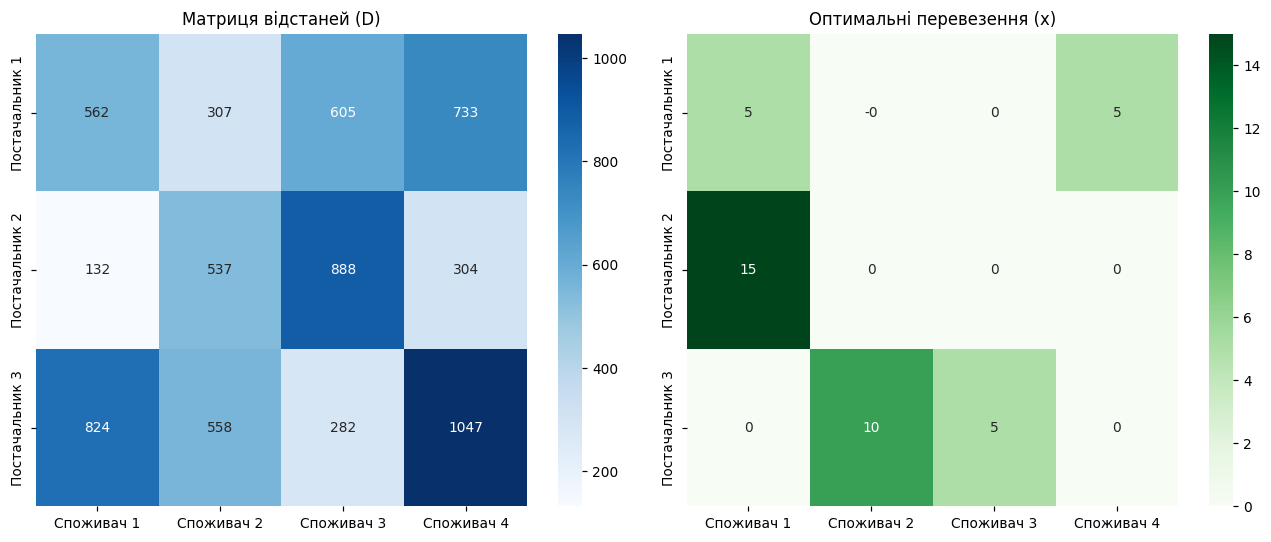

In [18]:
# ВАШ КОД
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

X = result.x.reshape(3, 4)

supply_labels = [f'Постачальник {i+1}' for i in range(D.shape[0])]
demand_labels = [f'Споживач {j+1}' for j in range(D.shape[1])]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(D, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=demand_labels, yticklabels=supply_labels,
            ax=axes[0], cbar=True)
axes[0].set_title('Матриця відстаней (D)')

sns.heatmap(X, annot=True, fmt='.0f', cmap='Greens',
            xticklabels=demand_labels, yticklabels=supply_labels,
            ax=axes[1], cbar=True)
axes[1].set_title('Оптимальні перевезення (x)')

plt.tight_layout()
plt.show()

**Висновок:** *(одне речення про те, що видно на теплових картах)*
Оптимальний план уникає найдорожчих перевезень, оскільки алгоритм мінімізує сумарну вартість тому уникає дорогі перевезення.

---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [19]:
ІНСТРУМЕНТИ_ШІ = 'Claude AI'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'текст, перероблено',
    'етап 2, побудова моделі в Excel':      'ні',
    'етап 3, код на Python':                'код, перевірено',
    'етапи 4–5, читання та перевірка звіту':'синтаксис',
    'етап 6, рішення про закупівлю':        'код, перевірено',
    'етапи 7–8, перевірка та цілочисельність': 'код, перевірено',
    'етапи 9–11, транспортна задача':       'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = 'Текст поправляв місцями на власний лад, переформульовував на правильніший варіант. Код в основному був написаний правильно. Також питав синтаксис про функцію linprog і старався писати сам код.'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [20]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Фарина Арсеній
інструменти:                               Claude AI
------------------------------------------------------------------------------
етап 1, формалізація моделі:               текст, перероблено
етап 2, побудова моделі в Excel:           ні
етап 3, код на Python:                     код, перевірено
етапи 4–5, читання та перевірка звіту:     синтаксис
етап 6, рішення про закупівлю:             код, перевірено
етапи 7–8, перевірка та цілочисельність:   код, перевірено
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------
Текст поправляв місцями на власний лад, переформульовував на правильніший варіант. Код в основному був написаний правильно. Також питав синтаксис про функцію linprog і старався писати сам код.


---
# Крок 13. Фінальна самоперевірка

In [21]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
